In [1]:
import os
from pathlib import Path

# Asegurar que el kernel corre desde notebooks/ para que ../data y ../outputs funcionen
_cwd = Path.cwd()
if _cwd.name != "notebooks":
    _nb_dir = _cwd / "notebooks"
    if _nb_dir.is_dir():
        os.chdir(_nb_dir)

# Crear directorios si no existen
for _d in ["../outputs", "../data", "../models"]:
    Path(_d).mkdir(exist_ok=True)

print(f"cwd: {Path.cwd()}")

cwd: c:\Users\adria\OneDrive\Desktop\Proyecto de machine learning\notebooks


# Fase 3 — Análisis de Sentimiento con FinBERT

En esta fase aplicamos **FinBERT** a cada transcripción de earnings call para obtener un puntaje de sentimiento.

**Objetivo:** Para cada par (ticker, trimestre), obtener:
- `sentimiento`: `positive`, `negative`, o `neutral`
- `score_positivo`: probabilidad de sentimiento positivo (0 a 1)
- `score_negativo`: probabilidad de sentimiento negativo (0 a 1)

Estos scores serán las **features** que alimentarán el modelo de predicción en la Fase 4.

---

### ¿Qué es BERT y por qué funciona para texto financiero?

**BERT** (Bidirectional Encoder Representations from Transformers) es un modelo de lenguaje entrenado por Google en millones de textos. A diferencia de los modelos anteriores que leían izquierda a derecha, BERT lee el texto en **ambas direcciones** al mismo tiempo, lo que le permite entender el contexto completo de cada palabra.

**FinBERT** es BERT pero re-entrenado específicamente en noticias financieras, reportes anuales y earnings calls. Esto es importante porque el lenguaje financiero tiene frases como *"headwinds in margins"* o *"beat estimates"* que un modelo de propósito general interpretaría de manera diferente.

**El límite de 512 tokens:** BERT solo puede procesar 512 tokens a la vez (aprox. 380 palabras). Como nuestras transcripciones son más largas, vamos a **truncar** el texto a 512 tokens. Esto es válido porque las primeras palabras de las earnings calls suelen ser las más importantes (el CEO resume los resultados al comienzo).

## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.nn.functional import softmax

print('Librerías cargadas correctamente')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU disponible: {torch.cuda.is_available()} (si es False, usamos CPU — está bien)')

Librerías cargadas correctamente
PyTorch version: 2.11.0+cpu
GPU disponible: False (si es False, usamos CPU — está bien)


## 2. Cargar las transcripciones limpias

Leemos el CSV que generamos en la Fase 2. 

In [3]:
df = pd.read_csv('../data/transcripciones_clean.csv')
print(f'Shape: {df.shape}')
print(f'\nColumnas: {df.columns.tolist()}')
print(f'\nDistribución por ticker:')
print(df['ticker'].value_counts())
df.head(5)

Shape: (92, 4)

Columnas: ['ticker', 'date', 'q', 'texto']

Distribución por ticker:
ticker
AAPL     12
GOOGL    12
TSLA     11
AMZN      9
META      8
JPM       7
AMD       6
MA        6
NFLX      6
V         6
NVDA      5
MSFT      4
Name: count, dtype: int64


,ticker,date,q,texto
0,AAPL,"Oct 29, 2020, 5:00 p.m. ET",2020-Q4,"the reception that we've gotten so far, we're ..."
1,NVDA,"Nov 14, 2019, 5:30 p.m. ET",2019-Q3,recently ventured into and we've been building...
2,GOOGL,"Oct 26, 2021, 4:30 p.m. ET",2021-Q3,ver the years? And what do you envision a hard...
3,GOOGL,"Apr 27, 2021, 5:00 p.m. ET",2021-Q1,"or the past four years, and we are working tow..."
4,AMZN,"Feb 02, 2021, 5:30 p.m. ET",2020-Q4,"more strongly with Prime benefits in 2020, and..."


## 3. Cargar el modelo FinBERT

La primera vez que ejecutes esta celda va a **descargar el modelo desde Hugging Face** (~440 MB). Las siguientes veces lo carga desde caché local.

### ¿Qué es un Tokenizer?

El tokenizer convierte texto en números que el modelo puede procesar. Por ejemplo:
- Texto: `"revenue grew strongly"`
- Tokens: `["revenue", "grew", "strong", "##ly"]`
- IDs: `[12984, 2992, 2844, 4168]`

El modelo no ve palabras, ve vectores de números. El tokenizer es el puente entre texto y números.

In [4]:
import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"  # carga desde caché local

MODEL_NAME = "ProsusAI/finbert"

print("Cargando FinBERT desde caché local...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

LABELS = model.config.id2label
print(f"Modelo cargado correctamente")
print(f"Clases del modelo: {LABELS}")

Cargando FinBERT desde caché local...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo cargado correctamente
Clases del modelo: {0: 'positive', 1: 'negative', 2: 'neutral'}


## 4b. Features de keywords financieras

FinBERT captura el tono general, pero el lenguaje corporativo puede ser tan diplomático que el modelo lo clasifica como `neutral` aunque el contenido sea negativo. Para complementarlo, contamos palabras clave financieras positivas y negativas directamente en el texto.

Esto nos da dos features adicionales con varianza más directa, especialmente útiles cuando el ejecutivo dice cosas como *"challenging environment"*, *"missed guidance"* o *"subscriber loss"*.

In [5]:
KEYWORDS_POSITIVOS = [
    'record', 'beat', 'exceeded', 'outperform', 'strong growth', 'raised guidance',
    'robust', 'momentum', 'accelerat', 'all-time high', 'double-digit growth',
    'margin expansion', 'significant growth', 'exceeding expectations', 'overperform',
    'best ever', 'breakthrough', 'strength', 'resilient', 'positive outlook'
]

KEYWORDS_NEGATIVOS = [
    'miss', 'missed', 'below expectations', 'headwind', 'challenging', 'difficult',
    'slowdown', 'decline', 'decrease', 'disappointing', 'uncertainty', 'pressure',
    'weakness', 'cautious', 'lowered guidance', 'margin compression', 'subscriber loss',
    'reduced forecast', 'below guidance', 'underperform', 'concern', 'deteriorat',
    'loss of subscribers', 'revenue decline', 'profit warning'
]

def contar_keywords(texto):
    texto_lower = texto.lower()
    pos = sum(1 for k in KEYWORDS_POSITIVOS if k in texto_lower)
    neg = sum(1 for k in KEYWORDS_NEGATIVOS if k in texto_lower)
    total = pos + neg
    ratio = (pos - neg) / (total + 1)  # +1 para evitar división por cero
    return {'kw_positivos': pos, 'kw_negativos': neg, 'kw_ratio': round(ratio, 4)}

# Test rápido
ejemplos_kw = [
    "We delivered record revenue and exceeded expectations with strong growth.",
    "We faced headwinds, missed guidance, and revenue declined due to challenging conditions.",
]
for e in ejemplos_kw:
    print(f'Texto: "{e[:65]}..."')
    print(f'  → {contar_keywords(e)}\n')

Texto: "We delivered record revenue and exceeded expectations with strong..."
  → {'kw_positivos': 3, 'kw_negativos': 0, 'kw_ratio': 0.75}

Texto: "We faced headwinds, missed guidance, and revenue declined due to ..."
  → {'kw_positivos': 0, 'kw_negativos': 6, 'kw_ratio': -0.8571}



## 4. Probar FinBERT con un ejemplo

Antes de procesar las transcripciones, probamos el modelo con frases cortas para verificar que funciona correctamente.

### ¿Qué devuelve FinBERT?

Devuelve **logits**: números crudos (pueden ser negativos o muy altos). Los convertimos a probabilidades con `softmax`, que los normaliza para que sumen 1.

In [6]:
def analizar_sentimiento(texto, max_length=512, stride=256):
    """
    Analiza el sentimiento dividiendo el texto en chunks solapados.
    Promedia los scores de todos los chunks para capturar toda la call.
    """
    # Tokenizamos el texto completo sin truncar
    tokens = tokenizer.encode(texto, add_special_tokens=False)
    
    # Si es corto, lo procesamos directo
    if len(tokens) <= max_length - 2:
        chunks = [tokens]
    else:
        # Dividimos en ventanas solapadas (stride = solapamiento entre chunks)
        chunks = []
        for start in range(0, len(tokens), stride):
            chunk = tokens[start : start + max_length - 2]
            chunks.append(chunk)
            if start + max_length - 2 >= len(tokens):
                break
    
    all_probs = []
    for chunk in chunks:
        # Reconstruimos el input con tokens especiales [CLS] y [SEP]
        input_ids = torch.tensor([[tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]])
        attention_mask = torch.ones_like(input_ids)
        
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
        probs = softmax(outputs.logits, dim=1).squeeze().numpy()
        all_probs.append(probs)
    
    # Promedio de todos los chunks
    mean_probs = np.mean(all_probs, axis=0)
    label_idx = mean_probs.argmax()
    
    return {
        'sentimiento':    LABELS[label_idx],
        'score_positivo': round(float(mean_probs[0]), 4),
        'score_negativo': round(float(mean_probs[1]), 4),
        'score_neutral':  round(float(mean_probs[2]), 4)
    }


# --- Test rápido ---
frases_test = [
    "We delivered record revenue and strong earnings growth this quarter.",
    "We faced significant headwinds and missed our revenue guidance.",
    "Revenue was in line with expectations for the period."
]

print('=== TEST DE VERIFICACIÓN ===\n')
for frase in frases_test:
    resultado = analizar_sentimiento(frase)
    print(f'Texto: "{frase[:70]}..."')
    print(f'  → {resultado}\n')

=== TEST DE VERIFICACIÓN ===

Texto: "We delivered record revenue and strong earnings growth this quarter...."
  → {'sentimiento': 'positive', 'score_positivo': 0.9591, 'score_negativo': 0.0168, 'score_neutral': 0.0241}

Texto: "We faced significant headwinds and missed our revenue guidance...."
  → {'sentimiento': 'negative', 'score_positivo': 0.0084, 'score_negativo': 0.9731, 'score_neutral': 0.0185}

Texto: "Revenue was in line with expectations for the period...."
  → {'sentimiento': 'positive', 'score_positivo': 0.9468, 'score_negativo': 0.025, 'score_neutral': 0.0282}



## 5. Aplicar FinBERT a todas las transcripciones

Procesamos todas las filas. En CPU puede tardar 15-20 minutos con ~90 transcripciones — es normal, FinBERT es un modelo pesado (~110 millones de parámetros).

El progreso se imprime cada 5 transcripciones.

In [7]:
def clasificar_kw_ratio(ratio):
    if ratio > 0:
        return 'positivo'
    elif ratio < 0:
        return 'negativo'
    else:
        return 'neutral'

resultados = []
total = len(df)

for i, (_, row) in enumerate(df.iterrows()):
    scores = analizar_sentimiento(row['texto'])
    kw = contar_keywords(row['texto'])
    polaridad = round(scores['score_positivo'] - scores['score_negativo'], 4)
    resultados.append({
        'ticker':          row['ticker'],
        'q':               row['q'],
        'date':            row['date'],
        'sentimiento':     scores['sentimiento'],
        'score_positivo':  scores['score_positivo'],
        'score_negativo':  scores['score_negativo'],
        'score_neutral':   scores['score_neutral'],
        'polaridad':       polaridad,
        'kw_positivos':    kw['kw_positivos'],
        'kw_negativos':    kw['kw_negativos'],
        'kw_ratio':        kw['kw_ratio'],
        'kw_categoria':    clasificar_kw_ratio(kw['kw_ratio']),
    })
    if (i + 1) % 5 == 0 or (i + 1) == total:
        print(f'  [{i+1}/{total}] {row["ticker"]} {row["q"]} → {scores["sentimiento"]} (pos={scores["score_positivo"]:.3f})')

df_sentimientos = pd.DataFrame(resultados)
print(f'\nShape: {df_sentimientos.shape}')
print(f'\nDistribución sentimiento:')
print(df_sentimientos['sentimiento'].value_counts())
print(f'\nDistribución kw_categoria:')
print(df_sentimientos['kw_categoria'].value_counts())
print(f'\nRango de polaridad: {df_sentimientos["polaridad"].min():.3f} → {df_sentimientos["polaridad"].max():.3f}')
df_sentimientos.head(10)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (951 > 512). Running this sequence through the model will result in indexing errors


  [5/92] AMZN 2020-Q4 → neutral (pos=0.121)
  [10/92] TSLA 2020-Q1 → neutral (pos=0.074)
  [15/92] AMD 2020-Q4 → neutral (pos=0.114)
  [20/92] AAPL 2022-Q3 → neutral (pos=0.222)
  [25/92] NVDA 2021-Q3 → neutral (pos=0.140)
  [30/92] MSFT 2021-Q3 → neutral (pos=0.264)
  [35/92] META 2021-Q4 → neutral (pos=0.094)
  [40/92] AAPL 2021-Q1 → neutral (pos=0.143)
  [45/92] GOOGL 2021-Q4 → neutral (pos=0.345)
  [50/92] V 2021-Q4 → neutral (pos=0.341)
  [55/92] AAPL 2021-Q4 → neutral (pos=0.062)
  [60/92] NFLX 2021-Q2 → neutral (pos=0.223)
  [65/92] AAPL 2020-Q3 → neutral (pos=0.151)
  [70/92] AMZN 2022-Q1 → neutral (pos=0.113)
  [75/92] TSLA 2021-Q3 → neutral (pos=0.214)
  [80/92] NVDA 2023-Q3 → neutral (pos=0.191)
  [85/92] MA 2021-Q1 → neutral (pos=0.200)
  [90/92] JPM 2022-Q1 → neutral (pos=0.054)
  [92/92] JPM 2022-Q3 → neutral (pos=0.072)

Shape: (92, 12)

Distribución sentimiento:
sentimiento
neutral     74
positive    18
Name: count, dtype: int64

Distribución kw_categoria:
kw_categoria


,ticker,q,date,sentimiento,score_positivo,score_negativo,score_neutral,polaridad,kw_positivos,kw_negativos,kw_ratio,kw_categoria
0,AAPL,2020-Q4,"Oct 29, 2020, 5:00 p.m. ET",neutral,0.4234,0.0134,0.5632,0.4100,2,0,0.6667,positivo
1,NVDA,2019-Q3,"Nov 14, 2019, 5:30 p.m. ET",neutral,0.0924,0.0246,0.8830,0.0678,0,2,-0.6667,negativo
2,GOOGL,2021-Q3,"Oct 26, 2021, 4:30 p.m. ET",neutral,0.1790,0.0116,0.8094,0.1674,1,0,0.5000,positivo
3,GOOGL,2021-Q1,"Apr 27, 2021, 5:00 p.m. ET",positive,0.6907,0.0127,0.2966,0.6780,4,1,0.5000,positivo
4,AMZN,2020-Q4,"Feb 02, 2021, 5:30 p.m. ET",neutral,0.1206,0.3612,0.5182,-0.2406,0,1,-0.5000,negativo
5,META,2022-Q1,"Apr 27, 2022, 5:00 p.m. ET",neutral,0.1539,0.0183,0.8279,0.1356,0,4,-0.8000,negativo
6,NVDA,2021-Q4,"Feb 24, 2021, 5:00 p.m. ET",neutral,0.0582,0.0304,0.9114,0.0278,0,0,0.0000,neutral
7,AAPL,2020-Q1,"Jan 28, 2020, 5:00 p.m. ET",neutral,0.2252,0.0161,0.7588,0.2091,1,0,0.5000,positivo
8,NVDA,2020-Q2,"Aug 15, 2019, 5:30 p.m. ET",neutral,0.0774,0.0202,0.9024,0.0572,0,0,0.0000,neutral
9,TSLA,2020-Q1,"Apr 29, 2020, 6:30 p.m. ET",neutral,0.0736,0.0190,0.9074,0.0546,0,0,0.0000,neutral


## 6. Explorar los resultados

¿Qué distribución de sentimientos encontramos? ¿Las earnings calls suelen ser positivas?

=== DISTRIBUCIÓN DE SENTIMIENTOS ===

sentimiento
neutral     74
positive    18
Name: count, dtype: int64

Score positivo promedio: 0.277
Score negativo promedio: 0.035

=== SENTIMIENTO PROMEDIO POR EMPRESA ===
        score_positivo  score_negativo
ticker                                
AAPL             0.239           0.027
AMD              0.448           0.030
AMZN             0.331           0.068
GOOGL            0.399           0.039
JPM              0.141           0.040
MA               0.340           0.024
META             0.253           0.043
MSFT             0.160           0.018
NFLX             0.168           0.018
NVDA             0.112           0.022
TSLA             0.233           0.037
V                0.393           0.021


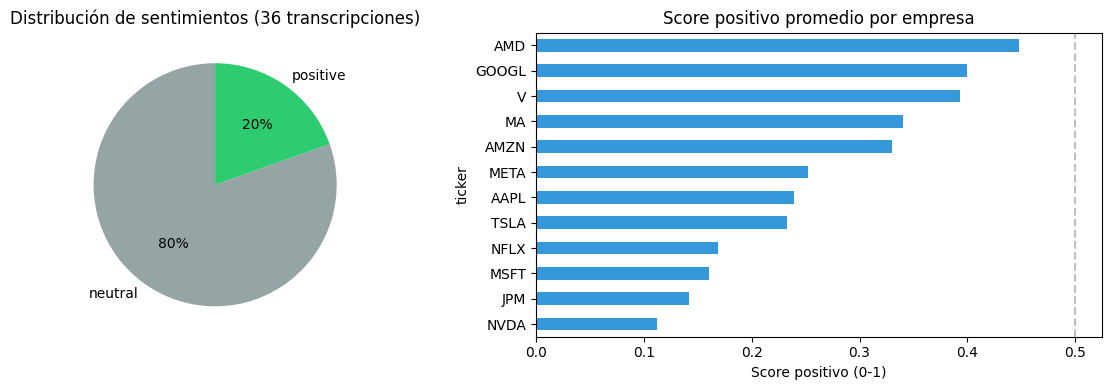

Gráfico guardado en outputs/sentimientos_distribucion.png


In [8]:
import matplotlib.pyplot as plt

# Distribución general
print('=== DISTRIBUCIÓN DE SENTIMIENTOS ===\n')
print(df_sentimientos['sentimiento'].value_counts())
print(f'\nScore positivo promedio: {df_sentimientos["score_positivo"].mean():.3f}')
print(f'Score negativo promedio: {df_sentimientos["score_negativo"].mean():.3f}')

# Distribución por ticker
print('\n=== SENTIMIENTO PROMEDIO POR EMPRESA ===')
print(df_sentimientos.groupby('ticker')[['score_positivo', 'score_negativo']].mean().round(3))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
conteo = df_sentimientos['sentimiento'].value_counts()
colores = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
axes[0].pie(
    conteo.values,
    labels=conteo.index,
    colors=[colores.get(l, 'gray') for l in conteo.index],
    autopct='%1.0f%%',
    startangle=90
)
axes[0].set_title('Distribución de sentimientos (36 transcripciones)')

# Score positivo por ticker
df_sentimientos.groupby('ticker')['score_positivo'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#3498db'
)
axes[1].set_title('Score positivo promedio por empresa')
axes[1].set_xlabel('Score positivo (0-1)')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/sentimientos_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico guardado en outputs/sentimientos_distribucion.png')

## 7. Guardar los resultados

Guardamos el DataFrame con los sentimientos para usarlo en la Fase 4 (feature engineering).

In [9]:
df_sentimientos.to_csv('../data/sentimientos.csv', index=False)
print(f'Guardado en data/sentimientos.csv')
print(f'Shape final: {df_sentimientos.shape}')
print(f'\nVista completa:')
print(df_sentimientos.to_string())

Guardado en data/sentimientos.csv
Shape final: (92, 12)

Vista completa:
   ticker        q                          date sentimiento  score_positivo  score_negativo  score_neutral  polaridad  kw_positivos  kw_negativos  kw_ratio kw_categoria
0    AAPL  2020-Q4    Oct 29, 2020, 5:00 p.m. ET     neutral          0.4234          0.0134         0.5632     0.4100             2             0    0.6667     positivo
1    NVDA  2019-Q3    Nov 14, 2019, 5:30 p.m. ET     neutral          0.0924          0.0246         0.8830     0.0678             0             2   -0.6667     negativo
2   GOOGL  2021-Q3    Oct 26, 2021, 4:30 p.m. ET     neutral          0.1790          0.0116         0.8094     0.1674             1             0    0.5000     positivo
3   GOOGL  2021-Q1    Apr 27, 2021, 5:00 p.m. ET    positive          0.6907          0.0127         0.2966     0.6780             4             1    0.5000     positivo
4    AMZN  2020-Q4    Feb 02, 2021, 5:30 p.m. ET     neutral          0.1206 